# Credit Market Analysis in Kyrgyzstan

This project analyzes commercial bank lending activity in Kyrgyzstan using data from the National Bank of the Kyrgyz Republic.

The analysis focuses on:
- Loan volumes
- Interest rates
- Economic sectors
- Credit market trends

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. IV.2.18 - New Loans by Sector

In [2]:
sheet_218 = pd.read_excel(
    "../data/credit_market_data.xls",
    sheet_name="IV.2.18",
    header=None
)

### Data Transformation

In [3]:
year_start_cols = {
    2018: 5,
    2019: 31,
    2020: 57,
    2021: 83,
    2022: 109,
    2023: 135,
    2024: 161,
    2025: 187,
    2026: 213
}

In [4]:
records = []
sector_start = 13
sector_end = 24

for year, start_col in year_start_cols.items():

    for month in range(1, 13):

        volume_col = start_col + (month - 1) * 2
        rate_col = volume_col + 1

        for row in range(sector_start, sector_end):

            records.append({
                "year": year,
                "month": month,
                "sector": sheet_218.iloc[row, 2],
                "loan_volume": sheet_218.iloc[row, volume_col],
                "interest_rate": sheet_218.iloc[row, rate_col]
            })

new_loans_df = pd.DataFrame(records)

new_loans_df.head()

,year,month,sector,loan_volume,interest_rate
0,2018,1,Industry,268.0675,12.247452
1,2018,1,Agriculture,751.6728,22.188632
2,2018,1,Transport,87.3519,18.645143
3,2018,1,Сommunication,-,-
4,2018,1,Trade,2363.8795,13.629507


In [5]:
new_loans_df = pd.DataFrame(records)
new_loans_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1188 entries, 0 to 1187
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   year           1188 non-null   int64 
 1   month          1188 non-null   int64 
 2   sector         1188 non-null   str   
 3   loan_volume    1078 non-null   object
 4   interest_rate  1078 non-null   object
dtypes: int64(2), object(2), str(1)
memory usage: 46.5+ KB


In [6]:
new_loans_df["loan_volume"] = pd.to_numeric(
    new_loans_df["loan_volume"],
    errors="coerce"
)

new_loans_df["interest_rate"] = pd.to_numeric(
    new_loans_df["interest_rate"],
    errors="coerce"
)

In [7]:
new_loans_df = new_loans_df[new_loans_df["year"] <= 2025]

### Data Validation

In [8]:
new_loans_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           1056 non-null   int64  
 1   month          1056 non-null   int64  
 2   sector         1056 non-null   str    
 3   loan_volume    1021 non-null   float64
 4   interest_rate  1021 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 41.4 KB


In [9]:
new_loans_df.isna().sum()

year              0
month             0
sector            0
loan_volume      35
interest_rate    35
dtype: int64

### Export Clean Dataset

In [10]:
new_loans_df.to_csv(
    "../data/new_loans_clean.csv",
    index=False
)

## 3. IV.2.21 - Outstanding Loans by Sector

In [11]:
sheet_221 = pd.read_excel(
    "../data/credit_market_data.xls",
    sheet_name="IV.2.21",
    header=None
)

### Data Transformation

In [12]:
year_start_cols = {
    2018: 5,
    2019: 31,
    2020: 57,
    2021: 83,
    2022: 109,
    2023: 135,
    2024: 161,
    2025: 187,
    2026: 213
}

In [13]:
records = []
sector_start = 13
sector_end = 24

for year, start_col in year_start_cols.items():

    for month in range(1, 13):

        volume_col = start_col + (month - 1) * 2
        rate_col = volume_col + 1

        for row in range(sector_start, sector_end):

            records.append({
                "year": year,
                "month": month,
                "sector": sheet_221.iloc[row, 2],
                "outstanding_loans": sheet_221.iloc[row, volume_col],
                "interest_rate": sheet_221.iloc[row, rate_col]
            })

outstanding_df = pd.DataFrame(records)

outstanding_df.head()

,year,month,sector,outstanding_loans,interest_rate
0,2018,1,Industry,10148.7631,11.074064
1,2018,1,Agriculture,20951.6426,17.987201
2,2018,1,Transport,1829.7625,17.616823
3,2018,1,Сommunication,140.5912,11.537664
4,2018,1,Trade,30869.5058,14.568942


In [14]:
outstanding_df = pd.DataFrame(records)
outstanding_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1188 entries, 0 to 1187
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               1188 non-null   int64  
 1   month              1188 non-null   int64  
 2   sector             1188 non-null   str    
 3   outstanding_loans  1078 non-null   float64
 4   interest_rate      1078 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 46.5 KB


In [15]:
outstanding_df["outstanding_loans"] = pd.to_numeric(
    outstanding_df["outstanding_loans"],
    errors="coerce"
)

outstanding_df["interest_rate"] = pd.to_numeric(
    outstanding_df["interest_rate"],
    errors="coerce"
)

outstanding_df = outstanding_df[
    outstanding_df["year"] <= 2025
]

### Data Validation

In [16]:
outstanding_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               1056 non-null   int64  
 1   month              1056 non-null   int64  
 2   sector             1056 non-null   str    
 3   outstanding_loans  1056 non-null   float64
 4   interest_rate      1056 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 41.4 KB


In [17]:
outstanding_df.isna().sum()

year                 0
month                0
sector               0
outstanding_loans    0
interest_rate        0
dtype: int64

### Export Clean Dataset

In [18]:
outstanding_df.to_csv(
    "../data/outstanding_loans_clean.csv",
    index=False
)

## 4. Regional Credit Portfolio

In [19]:
sheet_225 = pd.read_excel(
    "../data/credit_market_data.xls",
    sheet_name="IV.2.25",
    header=None
)

### Data Transformation

In [20]:
records = []

year_start_cols = {
    2018: 4,
    2019: 9,
    2020: 14,
    2021: 19,
    2022: 24,
    2023: 29,
    2024: 34,
    2025: 39
}

for region_row in range(10, 67, 8):

    region = sheet_225.iloc[region_row, 2]

    for year, start_col in year_start_cols.items():

        for quarter in range(1, 5):

            data_col = start_col + (quarter - 1)

            for sector_row in range(region_row + 1, region_row + 8):

                records.append({
                    "region": region,
                    "sector": sheet_225.iloc[sector_row, 2],
                    "year": year,
                    "quarter": quarter,
                    "loan_amount": sheet_225.iloc[sector_row, data_col]
                })

regional_df = pd.DataFrame(records)

regional_df.head()

,region,sector,year,quarter,loan_amount
0,Bishkek,Industry,2018,1,8210.739982
1,Bishkek,"Agriculture, procurement and processing",2018,1,2162.357604
2,Bishkek,Trade,2018,1,23417.608470
3,Bishkek,Construction,2018,1,6679.568582
4,Bishkek,Mortgage,2018,1,6698.826271


### Data Validation

In [21]:
regional_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1792 entries, 0 to 1791
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   region       1792 non-null   str    
 1   sector       1792 non-null   str    
 2   year         1792 non-null   int64  
 3   quarter      1792 non-null   int64  
 4   loan_amount  1792 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 70.1 KB


In [22]:
regional_df.isna().sum()

region         0
sector         0
year           0
quarter        0
loan_amount    0
dtype: int64

In [23]:
regional_df["loan_amount"].apply(type).value_counts()

loan_amount
<class 'float'>    1792
Name: count, dtype: int64

### Export Clean Dataset

In [24]:
regional_df.to_csv(
    "../data/regional_loans_clean.csv",
    index=False
)

## Data Cleaning Summary

Three datasets were extracted and transformed from the National Bank of Kyrgyzstan Statistical Bulletin:

1. New loans issued by sector
2. Outstanding loan portfolio by sector
3. Regional distribution of loans

All datasets were converted from wide to long format and checked for:
- missing values
- data types
- duplicate observations
- consistency of sector and regional classifications

## Data Visualization

### Visualization 1: Total New Loans by Sector

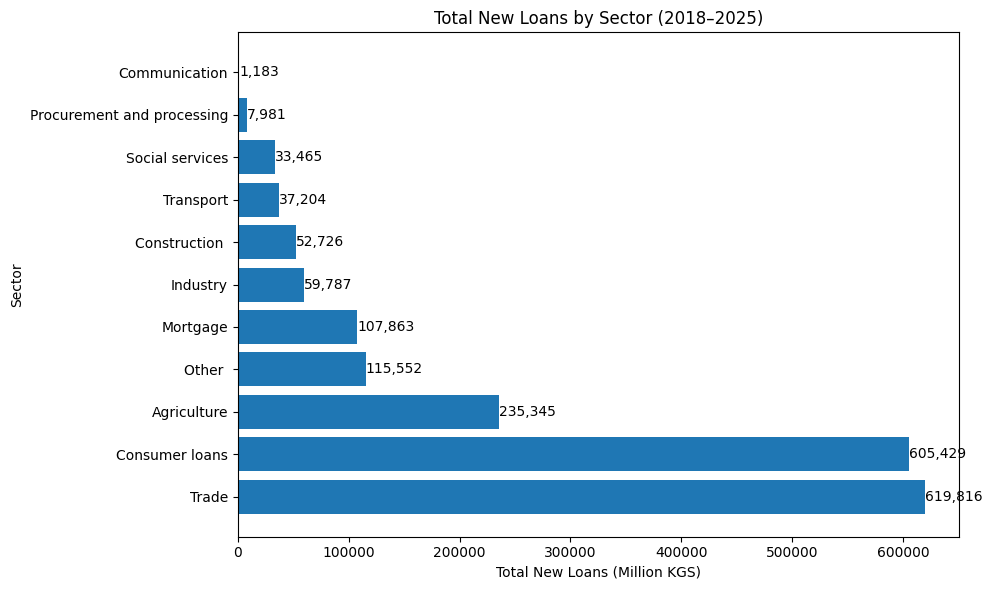

In [25]:
q1 = pd.read_csv(
    "../data/exports/query1_new_loans_by_sector.csv"
)
plt.figure(figsize=(10, 6))

bars = plt.barh(
    q1["sector"],
    q1["total_new_loans"]
)

plt.title("Total New Loans by Sector (2018–2025)")
plt.xlabel("Total New Loans (Million KGS)")
plt.ylabel("Sector")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center"
    )

plt.tight_layout()

# СНАЧАЛА СОХРАНЯЕМ
plt.savefig(
    "../visuals/new_loans_by_sector.png",
    dpi=300,
    bbox_inches="tight"
)

# ПОТОМ ПОКАЗЫВАЕМ
plt.show()

### Interpretation:
Trade and Consumer Loans received the largest volumes of newly issued credit between 2018 and 2025, accounting for
a substantial share of total lending activity. This suggests that commercial activity and household borrowing were the primary drivers of credit demand in Kyrgyzstan. In contrast, Communication and Procurement and Processing attracted very limited lending, indicating their relatively small role in the national credit market. 

### Visualization 2: Outstanding Loan Portfolio by Sector

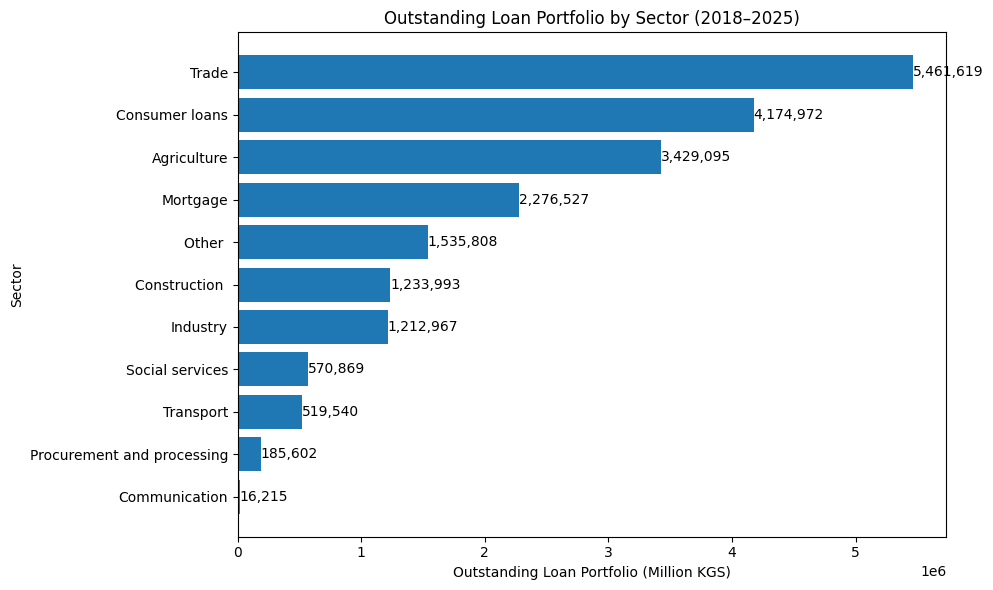

In [26]:
q3 = pd.read_csv(
    "../data/exports/query3_outstanding_portfolio_by_sector.csv"
)

q3_sorted = q3.sort_values(
    by="total_portfolio",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    q3_sorted["sector"],
    q3_sorted["total_portfolio"]
)

plt.title("Outstanding Loan Portfolio by Sector (2018–2025)")
plt.xlabel("Outstanding Loan Portfolio (Million KGS)")
plt.ylabel("Sector")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../visuals/outstanding_portfolio_by_sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation:
Trade holds the largest outstanding loan portfolio, followed by Consumer Loans and Agriculture. This indicates that these sectors not only receive substantial new lending but also accumulate the largest stock of outstanding credit over time. Together, they represent the core of the Kyrgyz credit market, while Communication remains a marginal segment in terms of portfolio size. 

### Visualization 3: Regional Market Share 

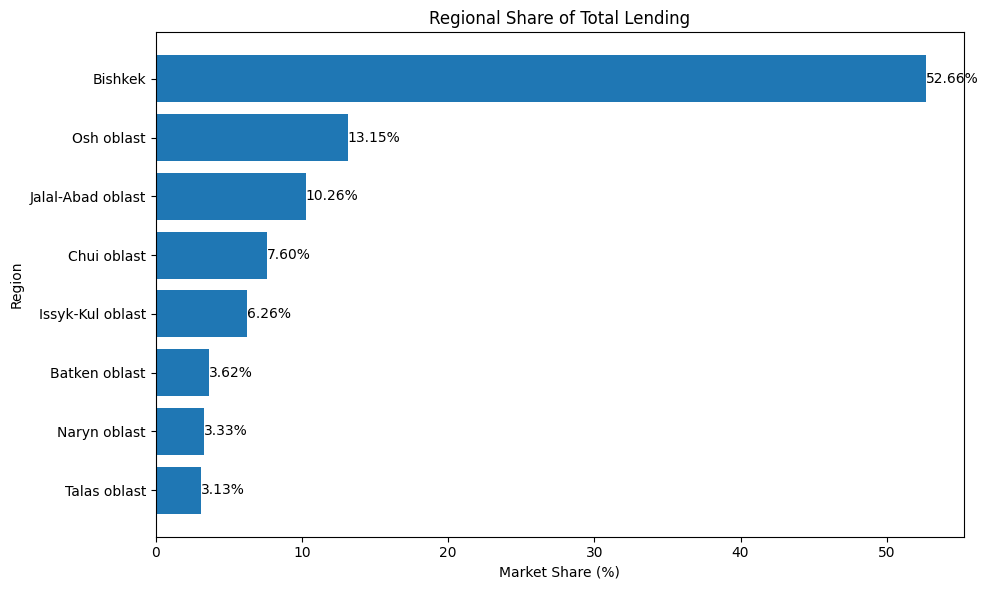

In [27]:
q5 = pd.read_csv(
    "../data/exports/query5_regional_market_share.csv"
)

q5_sorted = q5.sort_values(
    by="market_share_pct",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    q5_sorted["region"],
    q5_sorted["market_share_pct"]
)

plt.title("Regional Share of Total Lending")
plt.xlabel("Market Share (%)")
plt.ylabel("Region")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../visuals/regional_market_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation:
Lending activity in Kyrgyzstan is highly concentrated in Bishkek, which accounts for 52.66% of the total regional loan market. Osh oblast ranks a distant second with only 13.15%, while all remaining regions individually contribute less than 11% of total lending. This concentration highlights the dominant role of the capital in the country's financial system and suggests significant regional disparities in access to credit and economic activity.

### Visualization 4: Lending Growth by Sector

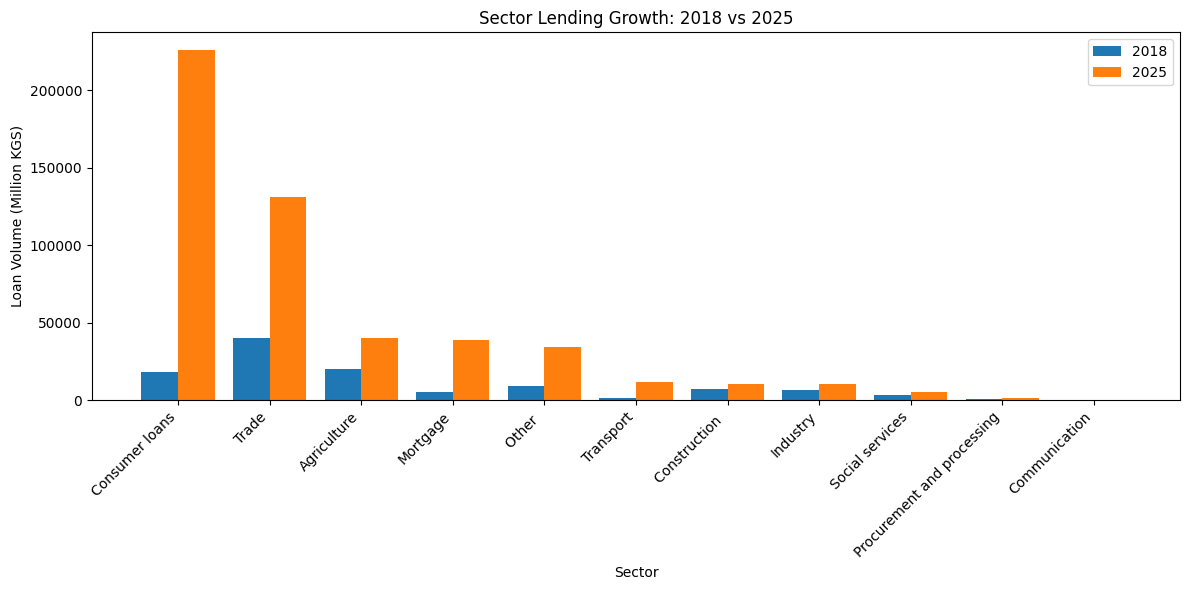

In [28]:
q2 = pd.read_csv(
    "../data/exports/query2_sector_growth.csv"
)

q2_plot = q2.sort_values(
    by="loans_2025",
    ascending=False
)

plt.figure(figsize=(12, 6))

x = range(len(q2_plot))

plt.bar(
    [i - 0.2 for i in x],
    q2_plot["loans_2018"],
    width=0.4,
    label="2018"
)

plt.bar(
    [i + 0.2 for i in x],
    q2_plot["loans_2025"],
    width=0.4,
    label="2025"
)

plt.xticks(
    x,
    q2_plot["sector"],
    rotation=45,
    ha="right"
)

plt.title("Sector Lending Growth: 2018 vs 2025")
plt.xlabel("Sector")
plt.ylabel("Loan Volume (Million KGS)")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../visuals/sector_growth_2018_vs_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation:
Consumer Loans were by far the largest contributor to credit market growth, increasing by more than 208 thousand million KGS between 2018 and 2025. Trade ranked second, although its contribution was less than half that of Consumer Loans. Most sectors experienced positive growth, while Communication was the only sector that declined over the period, suggesting either shrinking demand or limitations in the available data.

### Visualization 5: Change in Market Share by Sector

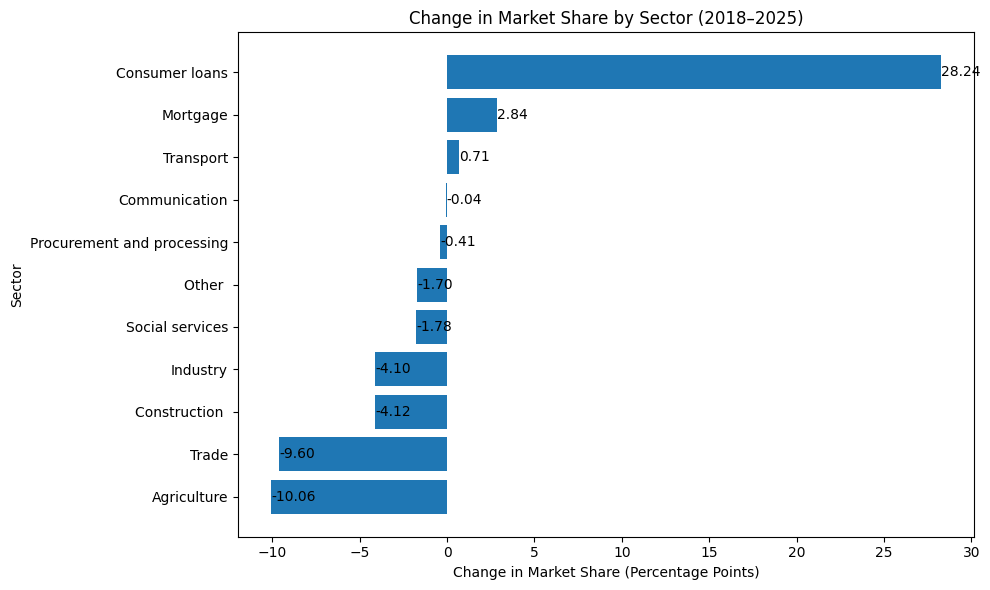

In [29]:
q9 = pd.read_csv(
    "../data/exports/query9_market_share_change.csv"
)

q9_sorted = q9.sort_values(
    by="market_share_change",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    q9_sorted["sector"],
    q9_sorted["market_share_change"]
)

plt.title("Change in Market Share by Sector (2018–2025)")
plt.xlabel("Change in Market Share (Percentage Points)")
plt.ylabel("Sector")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../visuals/market_share_change_by_sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation
Consumer Loans significantly increased their market share, rising from 15.94% in 2018 to 44.18% in 2025. This represents the largest structural change observed in the credit market. Mortgage and Transport also gained modest shares, while Trade and Agriculture experienced notable declines. The results suggest that the composition of lending shifted away from traditional business-oriented sectors toward household borrowing. 

## Key Findings

1. Trade and Consumer Loans dominated lending activity
Trade and Consumer Loans accounted for the largest volumes of newly issued credit between 2018 and 2025. Together, these sectors represented the core of lending activity in Kyrgyzstan.

2. Consumer Loans were the primary driver of market growth
Consumer lending increased by more than 208 billion KGS between 2018 and 2025, making it the fastest-growing major segment of the credit market.

3. Trade maintained the largest outstanding loan portfolio
Although Consumer Loans experienced stronger growth, Trade continued to hold the largest outstanding loan portfolio, indicating its long-term importance within the financial system.

4. Lending activity was highly concentrated in Bishkek
Bishkek accounted for more than 52% of total lending volume, significantly exceeding all other regions and highlighting strong regional concentration in the credit market.

5. The structure of the credit market shifted toward household borrowing
Consumer Loans increased their market share from 15.94% in 2018 to 44.18% in 2025, while Trade and Agriculture lost relative importance. This suggests a substantial shift in the composition of lending toward household credit.

## Conclusion

This project examined the structure and development of the Kyrgyz credit market between 2018 and 2025 using SQL and Python. Three datasets covering new loans, outstanding loan portfolios, and regional lending activity were analyzed to identify key trends and market characteristics.

The analysis revealed that Trade and Consumer Loans were the dominant sectors in terms of lending activity, while Consumer Loans emerged as the primary driver of market growth during the study period. Trade maintained the largest outstanding loan portfolio, demonstrating its continued importance within the financial system.

Regional analysis showed a high concentration of lending activity in Bishkek, which accounted for more than half of total loan volume. This finding suggests significant regional disparities in access to credit and economic activity.

The study also identified a structural shift in the composition of the credit market. Consumer Loans substantially increased their market share between 2018 and 2025, while traditionally important sectors such as Trade and Agriculture became relatively less dominant. This trend indicates growing importance of household borrowing within the Kyrgyz financial sector.

Overall, the results suggest that the Kyrgyz credit market experienced both expansion and structural transformation over the analyzed period, with lending activity becoming increasingly concentrated in consumer-oriented credit segments.